# PROTECT-90 EDA

Exploratory data analysis for the PROTECT-90 fault waveform dataset.

Goals:

- Inspect the label/metadata file.
- Check class balance for fault type and faulted line.
- Verify waveform files can be loaded.
- Plot voltage/current waveforms for selected episodes.
- Mark fault start/end time on waveform plots.
- Understand how to create train/validation/test splits and model windows.

## 1. Imports and Paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

LABELS_PATH = PROJECT_ROOT / "hv_double_line_90kv_labels.csv"
WAVEFORM_DIR = PROJECT_ROOT / "hv_double_line_90kv_preprocessed_data"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

LABELS_PATH, WAVEFORM_DIR

(PosixPath('/home/karan/Downloads/karan_docs/pridiction_maintainence detection and anamoly detection/hv_double_line_90kv_labels.csv'),
 PosixPath('/home/karan/Downloads/karan_docs/pridiction_maintainence detection and anamoly detection/hv_double_line_90kv_preprocessed_data'))

## 2. Load Labels

In [2]:
labels = pd.read_csv(LABELS_PATH)
labels.head()

,sample_id,t_evnt_start,t_evnt_end,sc_type,sc_location,phase_select,fault_target,fault_resistance,line_1_2_a_length,line_1_2_a_xline,...,ext_grid_1_u_setp,ext_grid_1_phi_setp,ext_grid_1_short_circuit_power,ext_grid_3_pgini,ext_grid_3_qgini,ext_grid_3_short_circuit_power,load_3_plini,load_3_qlini,load_2_plini,load_2_qlini
0,0,0.428642,0.694809,2,19.547918,1,Line_2_3_a,4.051499,27.309150,0.364453,...,1.004613,-75.273253,695.127767,-7.198320,17.733704,3409.444079,39.409698,7.644309,37.102466,-10.448473
1,1,0.469852,0.658022,3,87.564951,1,Line_2_3_a,7.549922,27.663943,0.419096,...,1.017557,-109.118615,1102.278894,3.653738,11.925011,1743.038515,42.591869,-19.779510,42.540816,11.845002
2,2,0.385552,0.737794,2,71.874684,1,Line_2_3_a,7.639229,22.898170,0.430234,...,0.973954,-63.970957,1394.238881,40.456113,19.854378,4068.004024,20.100093,18.527519,46.037416,-15.617183
3,3,0.339056,0.566060,3,62.977103,2,Line_2_3_a,5.064218,19.770858,0.392378,...,1.021161,-157.705335,563.299683,39.808226,-12.146809,241.640417,20.122082,-9.137236,46.885776,19.742252
4,4,0.264736,0.362889,1,75.769514,1,Line_2_3_a,2.730902,30.100211,0.369363,...,0.986479,110.983725,474.599487,12.829621,7.897955,1585.150287,38.932898,13.439547,25.991405,-9.524642


In [3]:
labels.shape, labels.columns.tolist()

((9022, 49),
 ['sample_id',
  't_evnt_start',
  't_evnt_end',
  'sc_type',
  'sc_location',
  'phase_select',
  'fault_target',
  'fault_resistance',
  'line_1_2_a_length',
  'line_1_2_a_xline',
  'line_1_2_a_rline',
  'line_1_2_a_cline',
  'line_1_2_a_xline0',
  'line_1_2_a_rline0',
  'line_1_2_a_cline0',
  'line_1_2_b_length',
  'line_1_2_b_xline',
  'line_1_2_b_rline',
  'line_1_2_b_cline',
  'line_1_2_b_xline0',
  'line_1_2_b_rline0',
  'line_1_2_b_cline0',
  'line_2_3_a_length',
  'line_2_3_a_xline',
  'line_2_3_a_rline',
  'line_2_3_a_cline',
  'line_2_3_a_xline0',
  'line_2_3_a_rline0',
  'line_2_3_a_cline0',
  'line_2_3_b_length',
  'line_2_3_b_xline',
  'line_2_3_b_rline',
  'line_2_3_b_cline',
  'line_2_3_b_xline0',
  'line_2_3_b_rline0',
  'line_2_3_b_cline0',
  'line_2_3_b_on',
  'line_1_2_b_on',
  'ext_grid_3_on',
  'ext_grid_1_u_setp',
  'ext_grid_1_phi_setp',
  'ext_grid_1_short_circuit_power',
  'ext_grid_3_pgini',
  'ext_grid_3_qgini',
  'ext_grid_3_short_circuit_power

In [4]:
labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 9022 entries, 0 to 9021
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   sample_id                       9022 non-null   int64  
 1   t_evnt_start                    9022 non-null   float64
 2   t_evnt_end                      9022 non-null   float64
 3   sc_type                         9022 non-null   int64  
 4   sc_location                     9022 non-null   float64
 5   phase_select                    9022 non-null   int64  
 6   fault_target                    9022 non-null   str    
 7   fault_resistance                9022 non-null   float64
 8   line_1_2_a_length               9022 non-null   float64
 9   line_1_2_a_xline                9022 non-null   float64
 10  line_1_2_a_rline                9022 non-null   float64
 11  line_1_2_a_cline                9022 non-null   float64
 12  line_1_2_a_xline0               9022 non-null

## 3. Missing Values and Basic Checks

In [5]:
missing = labels.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [6]:
labels.describe().T

,count,mean,std,min,25%,50%,75%,max
sample_id,9022.0,4571.290069,2639.687415,0.000000,2288.250000,4564.500000,6857.750000,9149.000000
t_evnt_start,9022.0,0.349245,0.086592,0.200021,0.274104,0.349526,0.424022,0.499996
t_evnt_end,9022.0,0.575583,0.138858,0.210369,0.477195,0.585937,0.691304,0.799724
sc_type,9022.0,1.492574,1.116186,0.000000,0.000000,1.000000,2.000000,3.000000
sc_location,9022.0,49.746076,28.948958,0.003557,24.594287,49.718183,74.638963,99.998798
phase_select,9022.0,1.010973,0.817169,0.000000,0.000000,1.000000,2.000000,2.000000
fault_resistance,9022.0,5.060380,2.838145,0.101793,2.588283,5.113586,7.479915,9.999295
line_1_2_a_length,9022.0,34.916802,14.369154,10.027555,22.565790,34.914701,47.165244,59.997299
line_1_2_a_xline,9022.0,0.399907,0.028920,0.350014,0.375013,0.399895,0.424832,0.449995
line_1_2_a_rline,9022.0,0.108842,0.049143,0.050000,0.057025,0.104290,0.152089,0.199995


## 4. Fault Class Distribution

`sc_type` is the main fault-type label. This is the first target we can use for supervised classification.

In [7]:
sc_counts = labels["sc_type"].value_counts().sort_index()
sc_counts

sc_type
0    2273
1    2251
2    2279
3    2219
Name: count, dtype: int64

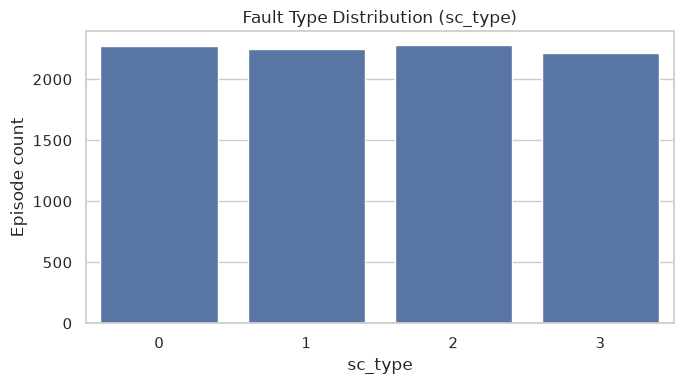

In [8]:
plt.figure(figsize=(7, 4))
sns.barplot(x=sc_counts.index.astype(str), y=sc_counts.values)
plt.title("Fault Type Distribution (sc_type)")
plt.xlabel("sc_type")
plt.ylabel("Episode count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "sc_type_distribution.png", dpi=150)
plt.show()

## 5. Faulted Line Distribution

`fault_target` tells which line/segment had the fault. This can be used for a second classification task.

In [9]:
target_counts = labels["fault_target"].value_counts()
target_counts

fault_target
Line_1_2_a    3191
Line_2_3_a    3165
Line_2_3_b    1338
Line_1_2_b    1328
Name: count, dtype: int64

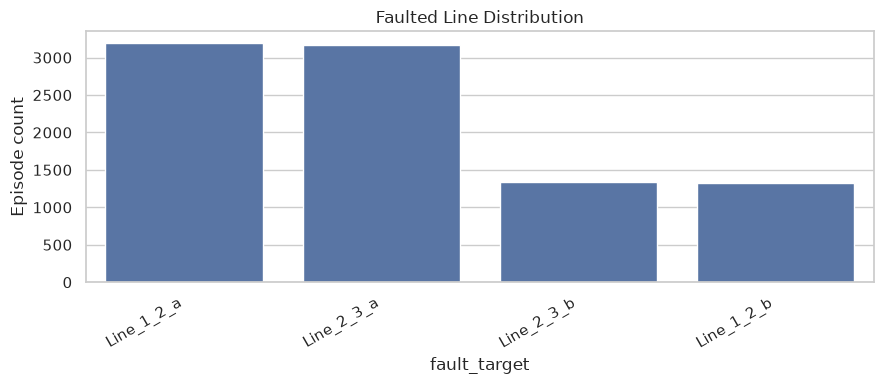

In [10]:
plt.figure(figsize=(9, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title("Faulted Line Distribution")
plt.xlabel("fault_target")
plt.ylabel("Episode count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fault_target_distribution.png", dpi=150)
plt.show()

## 6. Fault Timing Distribution

`t_evnt_start` and `t_evnt_end` let us mark each waveform window as pre-fault, fault, or post-fault.

In [11]:
labels["fault_duration_s"] = labels["t_evnt_end"] - labels["t_evnt_start"]
labels[["t_evnt_start", "t_evnt_end", "fault_duration_s"]].describe()

,t_evnt_start,t_evnt_end,fault_duration_s
count,9022.000000,9022.000000,9022.000000
mean,0.349245,0.575583,0.226338
std,0.086592,0.138858,0.140108
min,0.200021,0.210369,0.000012
25%,0.274104,0.477195,0.107591
50%,0.349526,0.585937,0.218352
75%,0.424022,0.691304,0.327306
max,0.499996,0.799724,0.594117


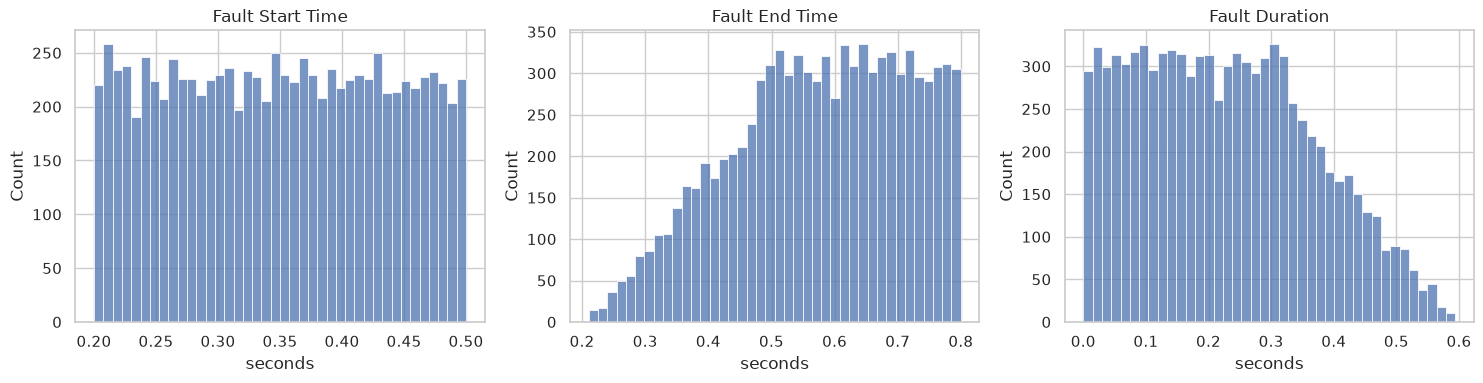

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(labels["t_evnt_start"], bins=40, ax=axes[0])
axes[0].set_title("Fault Start Time")
axes[0].set_xlabel("seconds")

sns.histplot(labels["t_evnt_end"], bins=40, ax=axes[1])
axes[1].set_title("Fault End Time")
axes[1].set_xlabel("seconds")

sns.histplot(labels["fault_duration_s"], bins=40, ax=axes[2])
axes[2].set_title("Fault Duration")
axes[2].set_xlabel("seconds")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fault_timing_distribution.png", dpi=150)
plt.show()

## 7. Verify Waveform Files

In [13]:
waveform_files = sorted(WAVEFORM_DIR.glob("*_sample_hv_double_line_90kv.pkl"))
len(waveform_files), waveform_files[:3]

(9022,
 [PosixPath('/home/karan/Downloads/karan_docs/pridiction_maintainence detection and anamoly detection/hv_double_line_90kv_preprocessed_data/0_sample_hv_double_line_90kv.pkl'),
  PosixPath('/home/karan/Downloads/karan_docs/pridiction_maintainence detection and anamoly detection/hv_double_line_90kv_preprocessed_data/1000_sample_hv_double_line_90kv.pkl'),
  PosixPath('/home/karan/Downloads/karan_docs/pridiction_maintainence detection and anamoly detection/hv_double_line_90kv_preprocessed_data/1001_sample_hv_double_line_90kv.pkl')])

In [14]:
available_ids = {
    int(path.name.split("_sample_")[0])
    for path in waveform_files
}
label_ids = set(labels["sample_id"].astype(int))

missing_waveforms = sorted(label_ids - available_ids)
extra_waveforms = sorted(available_ids - label_ids)

len(missing_waveforms), missing_waveforms[:10], len(extra_waveforms), extra_waveforms[:10]

(0, [], 0, [])

## 8. Load One Waveform Episode

In [15]:
def load_waveform(sample_id: int) -> pd.DataFrame:
    path = WAVEFORM_DIR / f"{sample_id}_sample_hv_double_line_90kv.pkl"
    return pd.read_pickle(path)


sample_id = int(labels.iloc[0]["sample_id"])
waveform = load_waveform(sample_id)

waveform.shape, waveform.columns.tolist()[:12], waveform.head()

((6400, 49),
 ['time_s',
  'Bus_1_Line_01_02A_cur_L1_A',
  'Bus_1_Line_01_02A_cur_L2_A',
  'Bus_1_Line_01_02A_cur_L3_A',
  'Bus_1_Line_01_02A_vol_L1_V',
  'Bus_1_Line_01_02A_vol_L2_V',
  'Bus_1_Line_01_02A_vol_L3_V',
  'Bus_1_Line_01_02B_cur_L1_A',
  'Bus_1_Line_01_02B_cur_L2_A',
  'Bus_1_Line_01_02B_cur_L3_A',
  'Bus_1_Line_01_02B_vol_L1_V',
  'Bus_1_Line_01_02B_vol_L2_V'],
      time_s  Bus_1_Line_01_02A_cur_L1_A  Bus_1_Line_01_02A_cur_L2_A  \
 0  0.000156                  336.670541                 -793.249168   
 1  0.000312                  371.671670                 -795.690564   
 2  0.000469                  405.777409                 -796.215072   
 3  0.000625                  438.905595                 -794.821428   
 4  0.000781                  470.976418                 -791.512990   
 
    Bus_1_Line_01_02A_cur_L3_A  Bus_1_Line_01_02A_vol_L1_V  \
 0                  456.578627                22247.422301   
 1                  424.018894                25674.571599   
 2

## 9. Identify Voltage and Current Channels

In [16]:
time_col = "time_s"
voltage_cols = [col for col in waveform.columns if "_vol_" in col]
current_cols = [col for col in waveform.columns if "_cur_" in col]

len(voltage_cols), voltage_cols[:12], len(current_cols), current_cols[:12]

(0, [], 0, [])

If the channel names differ from the simple `V_A` / `I_A` format, inspect the columns above and select the first measurement location manually.

In [17]:
first_signal_cols = [col for col in waveform.columns if col != time_col][:6]
first_signal_cols

['Bus_1_Line_01_02A_cur_L1_A',
 'Bus_1_Line_01_02A_cur_L2_A',
 'Bus_1_Line_01_02A_cur_L3_A',
 'Bus_1_Line_01_02A_vol_L1_V',
 'Bus_1_Line_01_02A_vol_L2_V',
 'Bus_1_Line_01_02A_vol_L3_V']

## 10. Plot One Episode With Fault Start/End

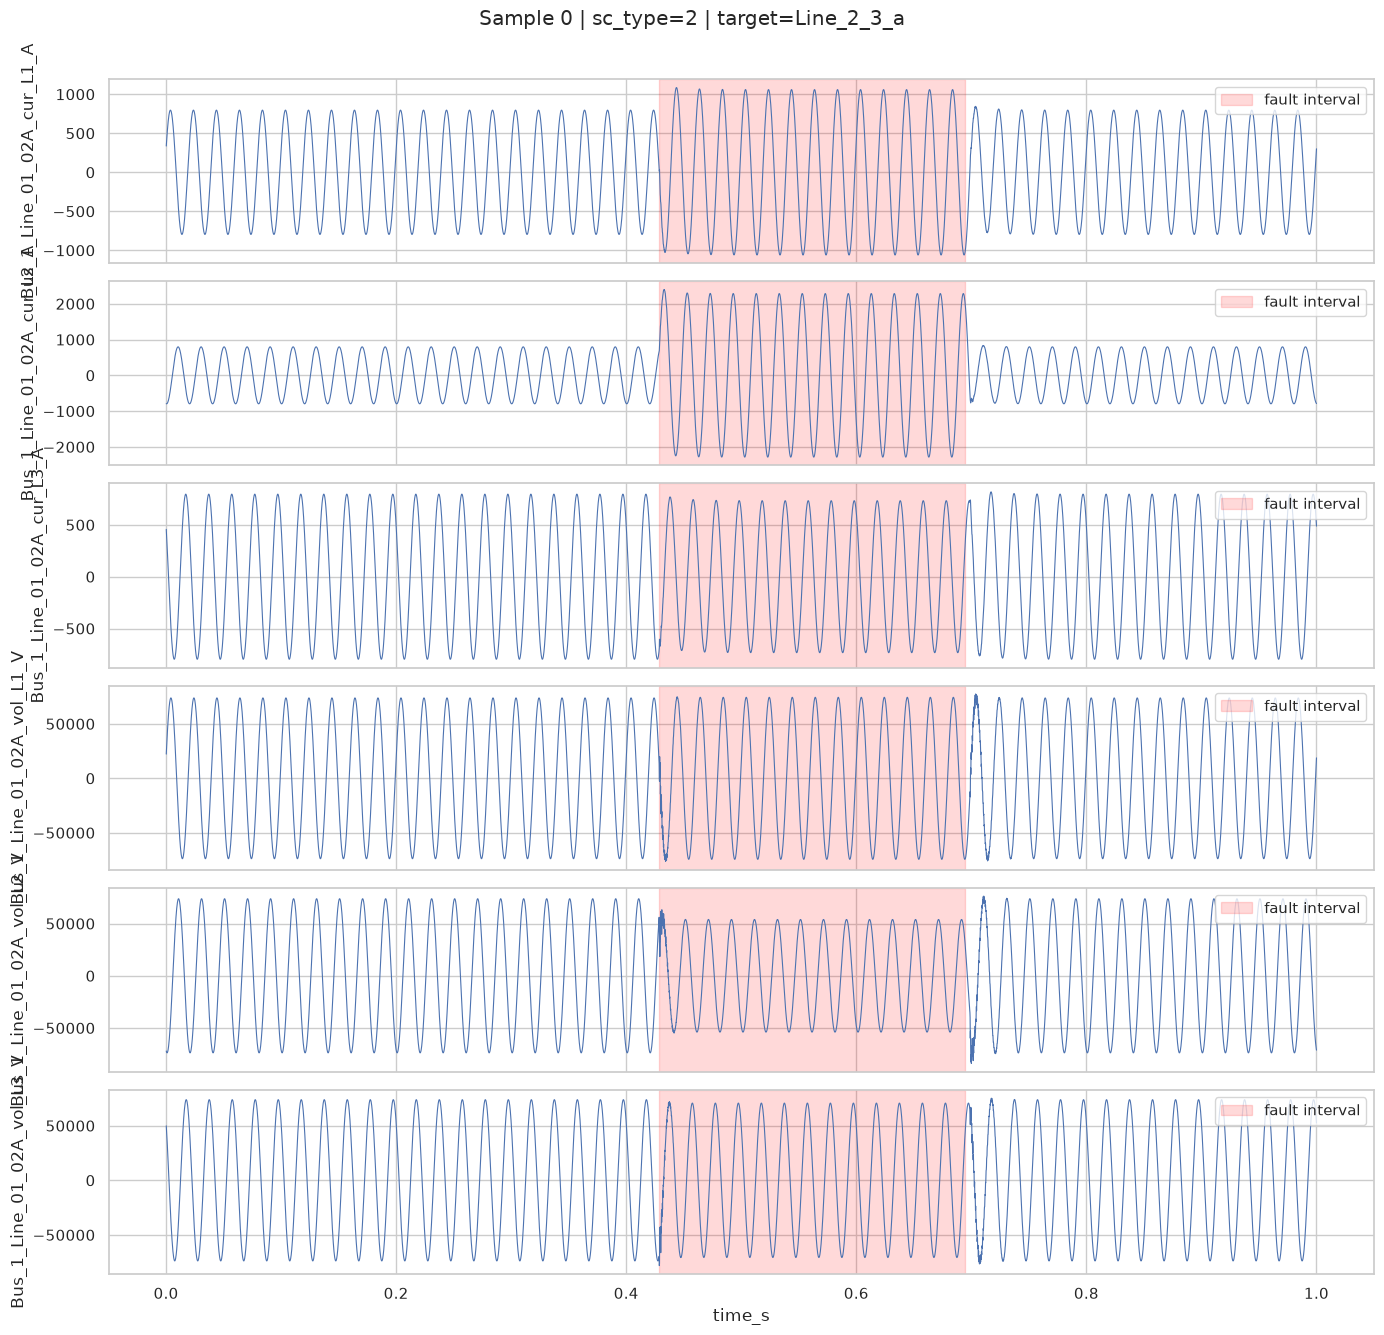

In [18]:
def plot_episode(sample_id: int, channels: list[str] | None = None) -> None:
    row = labels.loc[labels["sample_id"] == sample_id].iloc[0]
    df = load_waveform(sample_id)
    channels = channels or [col for col in df.columns if col != "time_s"][:6]

    fig, axes = plt.subplots(len(channels), 1, figsize=(14, 2.2 * len(channels)), sharex=True)
    if len(channels) == 1:
        axes = [axes]

    for ax, channel in zip(axes, channels):
        ax.plot(df["time_s"], df[channel], linewidth=0.8)
        ax.axvspan(row["t_evnt_start"], row["t_evnt_end"], color="red", alpha=0.15, label="fault interval")
        ax.set_ylabel(channel)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("time_s")
    fig.suptitle(
        f"Sample {sample_id} | sc_type={row['sc_type']} | target={row['fault_target']}",
        y=1.01,
    )
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"sample_{sample_id}_waveform.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_episode(sample_id, first_signal_cols)

## 11. Compare One Example Per Fault Type

In [19]:
example_ids = labels.groupby("sc_type")["sample_id"].first().astype(int).tolist()
example_ids

[5, 4, 0, 1]

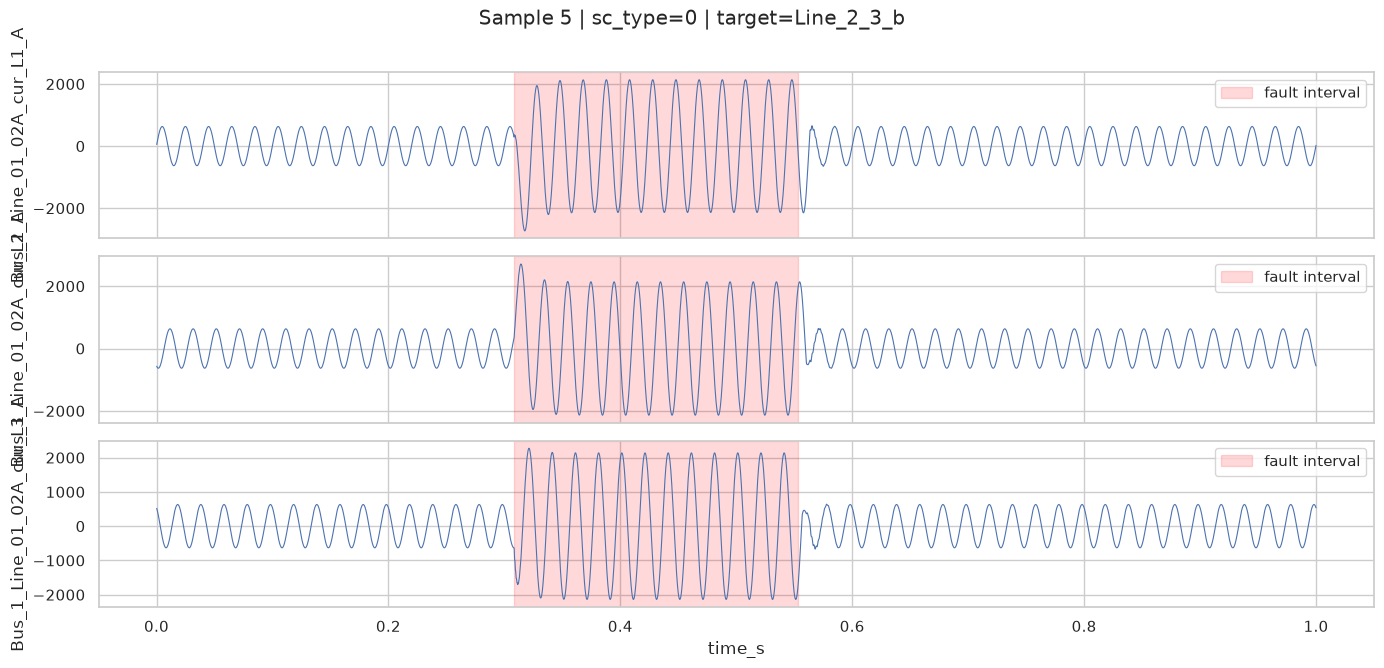

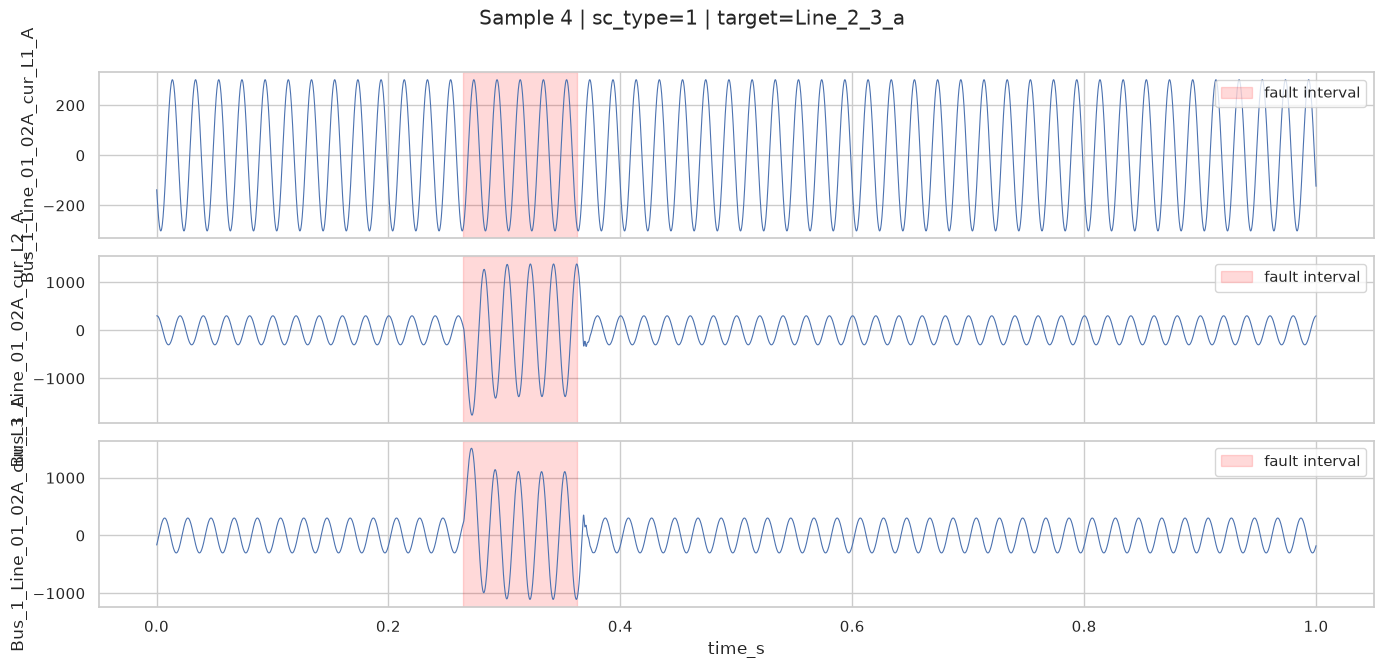

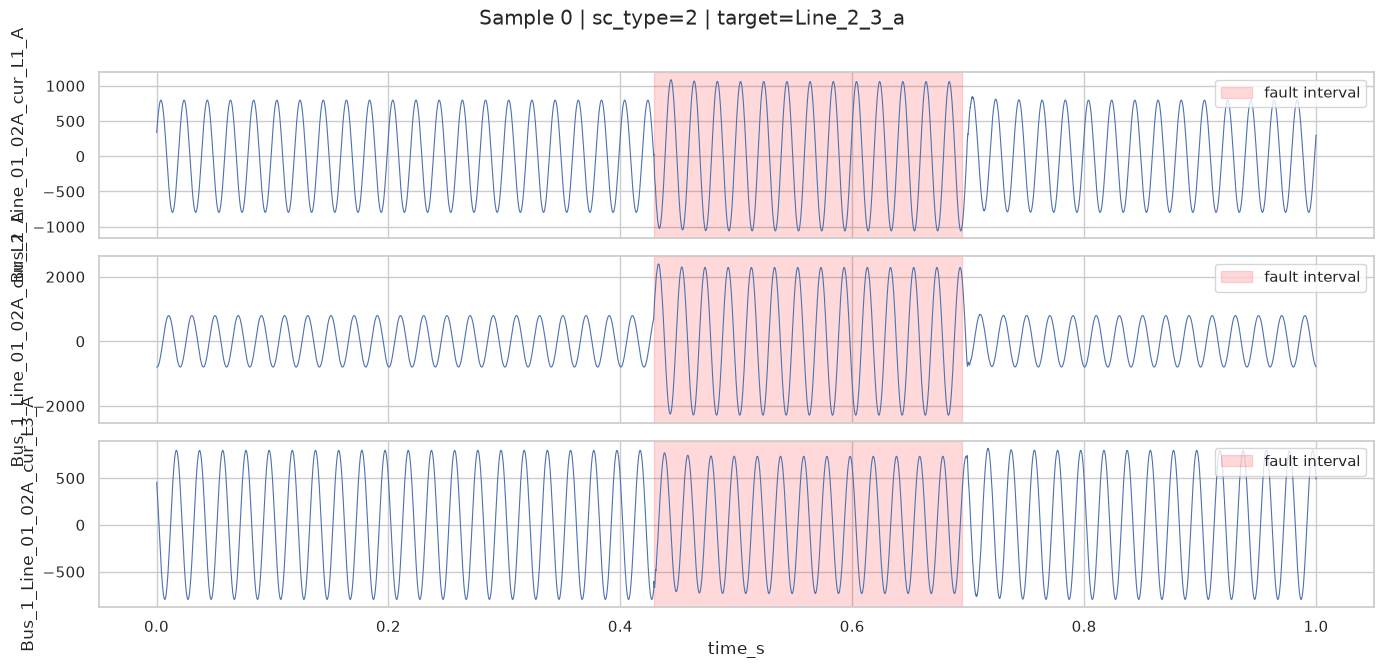

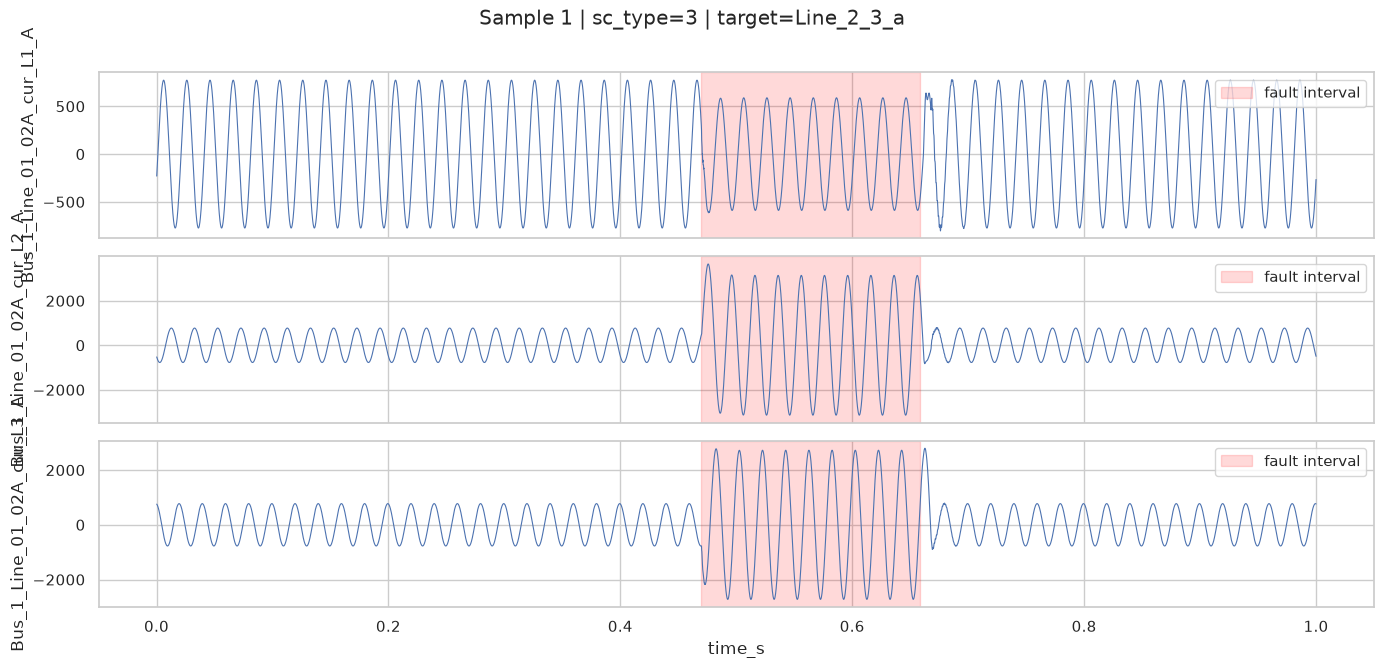

In [20]:
for sid in example_ids:
    plot_episode(sid, first_signal_cols[:3])

## 12. Windowing Plan

The dataset is sampled at 6.4 kHz. For a 50 Hz system:

- 1 cycle = 20 ms = 128 samples
- 5 cycles = 100 ms = 640 samples
- 10 cycles = 200 ms = 1280 samples

Recommended first experiment: 5-cycle windows with 1-cycle stride.

In [21]:
SAMPLE_RATE_HZ = 6400
GRID_FREQ_HZ = 50
SAMPLES_PER_CYCLE = SAMPLE_RATE_HZ // GRID_FREQ_HZ

WINDOW_SAMPLES = 5 * SAMPLES_PER_CYCLE
STRIDE_SAMPLES = 1 * SAMPLES_PER_CYCLE

SAMPLES_PER_CYCLE, WINDOW_SAMPLES, STRIDE_SAMPLES

(128, 640, 128)

In [22]:
def label_window(start_time: float, end_time: float, fault_start: float, fault_end: float) -> str:
    if end_time < fault_start:
        return "normal"
    if start_time <= fault_end and end_time >= fault_start:
        return "fault"
    return "post_fault"


row = labels.loc[labels["sample_id"] == sample_id].iloc[0]
window_rows = []
for start in range(0, len(waveform) - WINDOW_SAMPLES + 1, STRIDE_SAMPLES):
    end = start + WINDOW_SAMPLES
    start_time = float(waveform.iloc[start]["time_s"])
    end_time = float(waveform.iloc[end - 1]["time_s"])
    window_rows.append(
        {
            "sample_id": sample_id,
            "start_idx": start,
            "end_idx": end,
            "start_time": start_time,
            "end_time": end_time,
            "window_label": label_window(start_time, end_time, row["t_evnt_start"], row["t_evnt_end"]),
            "sc_type": row["sc_type"],
        }
    )

window_preview = pd.DataFrame(window_rows)
window_preview.head(), window_preview["window_label"].value_counts()

(   sample_id  start_idx  end_idx  start_time  end_time window_label  sc_type
 0          0          0      640    0.000156      0.10       normal        2
 1          0        128      768    0.020156      0.12       normal        2
 2          0        256      896    0.040156      0.14       normal        2
 3          0        384     1024    0.060156      0.16       normal        2
 4          0        512     1152    0.080156      0.18       normal        2,
 window_label
 fault         18
 normal        17
 post_fault    11
 Name: count, dtype: int64)

## 13. Next Steps

After this EDA:

1. Create `data/splits/protect90_split.csv` by `sample_id`.
2. Build a window dataset generator.
3. Extract baseline features from each window.
4. Train a RandomForest/XGBoost baseline.
5. Train a 1D-CNN on raw windows.
6. Replay held-out test waveforms through Kafka for real-time inference testing.